In [70]:
from pathlib import Path

OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-single-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1")

# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_candidates = [
    OUTPUTS_ROOT / "train_epochs100_augment0_lr0.005_es15_202607151440",  # Semantic fusion on
    OUTPUTS_ROOT / "train_epochs100_augment0_lr0.005_nosf_es15_202607141709",  # Semantic fusion off
]
run_dirs = [p for p in run_candidates if p.is_dir() and (p / "params.yaml").exists()]

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 2 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-single-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_es15_202607151440
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-single-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_nosf_es15_202607141709


In [71]:
import yaml
import pandas as pd

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "rm_semantic_fusion": doc["params"]["rm_semantic_fusion"] if "rm_semantic_fusion" in doc["params"] else False,
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }


configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)

comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["rm_semantic_fusion"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,rm_semantic_fusion,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,mcc_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_es15_20260715...,False,269,0.041544,1138,0.1977,0.122681,0.025874,0.960234,...,0.017122,0.921847,0.012405,0.964126,0.004256,0.940771,0.009365,106.540,26.495570,532.70
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_nosf_es15_202...,True,269,0.041544,1138,0.1977,0.094206,0.025464,0.962573,...,0.022704,0.925462,0.016258,0.967797,0.007473,0.944316,0.012203,64.016,10.302661,320.08


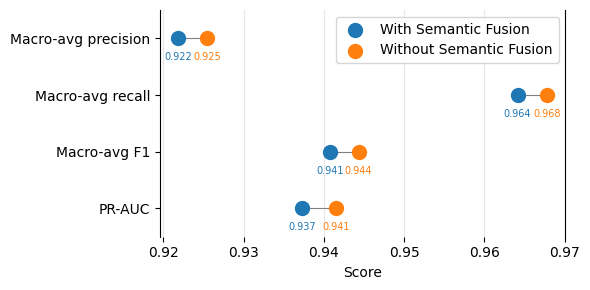

In [72]:
import numpy as np

# Cleveland dot plot: metrics on y, score on x; one colored dot per evaluation
import matplotlib.pyplot as plt

plot_df = comparison_df.copy()
plot_df["evaluation"] = plot_df["rm_semantic_fusion"].map({False: "With Semantic Fusion", True: "Without Semantic Fusion"})
evals = plot_df["evaluation"].tolist()
metric_cols = [
    "precision_macro_mean",
    "recall_macro_mean",
    "f1_macro_mean",
    "pr_auc_mean"
]
y = np.arange(len(metric_cols))
labels = [
    "Macro-avg precision",
    "Macro-avg recall",
    "Macro-avg F1",
    "PR-AUC"
]

fig, ax = plt.subplots(figsize=(6, 3))

# map evaluations to distinct colors
unique_evals = plot_df["evaluation"].unique().tolist()
cmap = plt.get_cmap("tab10")
color_map = {ev: cmap(i) for i, ev in enumerate(unique_evals)}

# draw grey connector lines for each metric
for i in range(len(metric_cols)):
    vals = plot_df[metric_cols].iloc[:, i] if False else plot_df[metric_cols].iloc[:, i]  # noop for clarity
for i in range(len(metric_cols)):
    # values for this metric across evaluations (respect row order)
    vals = plot_df[metric_cols].iloc[:, i].to_numpy()  # not used; keep loop for connector below

# connector and points (use the row order in plot_df)
for i, metric in enumerate(metric_cols):
    vals = plot_df[metric].to_numpy(dtype=float)
    ax.plot(vals, [i, i], color="gray", linewidth=0.8, zorder=1)
for ev_name in evals:
    row = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0]
    for i, metric in enumerate(metric_cols):
        ax.annotate(
            f"{row[metric]:.3f}",
            (row[metric], i),
            textcoords="offset points",
            xytext=(0, -10),
            ha="center",
            va="top",
            fontsize=7,
            color=color_map[ev_name],
        )
    vals = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0].to_numpy(dtype=float)
    ax.scatter(vals, y, s=100, color=color_map[ev_name], label=ev_name, zorder=2)

ax.set_yticks(y)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim(y.min() - 0.5, y.max() + 0.5)

ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Score")
ax.grid(axis="x", alpha=0.3)
# set x limits with a small margin
all_vals = plot_df[metric_cols].to_numpy(dtype=float)
xmin, xmax = all_vals.min(), all_vals.max()
pad = (xmax - xmin) * 0.05 if xmax > xmin else 0.01
ax.set_xlim(xmin - pad, xmax + pad)
ax.legend()
plt.tight_layout()
plt.show()



In [73]:
trimmed_df = comparison_df[[
    "rm_semantic_fusion",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,rm_semantic_fusion,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,f1_normal_std,precision_anomaly_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,False,0.960234,0.006820,0.992435,0.000067,0.957664,0.008512,0.974721,0.004464,0.851259,...,0.970588,1.110223e-16,0.906822,0.014266,0.943978,0.00625,0.937248,0.034458,106.540,26.495570
1,True,0.962573,0.008752,0.993961,0.003021,0.959124,0.010925,0.976196,0.005698,0.856963,...,0.976471,1.176471e-02,0.912437,0.018714,0.949697,0.01139,0.941480,0.025893,64.016,10.302661


In [76]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "Semantic Fusion", (trimmed_df["rm_semantic_fusion"].map({False: "Included", True: "Not Included"})))
display_df = display_df.set_index("Semantic Fusion")

final_table = display_df.T
final_table

Semantic Fusion,Included,Not Included
accuracy,96.02 ± 00.68,96.26 ± 00.88
precision_normal,99.24 ± 00.01,99.40 ± 00.30
recall_normal,95.77 ± 00.85,95.91 ± 01.09
f1_normal,97.47 ± 00.45,97.62 ± 00.57
precision_anomaly,85.13 ± 02.47,85.70 ± 03.26
recall_anomaly,97.06 ± 00.00,97.65 ± 01.18
f1_anomaly,90.68 ± 01.43,91.24 ± 01.87
f2_anomaly,94.40 ± 00.63,94.97 ± 01.14
pr_auc,93.72 ± 03.45,94.15 ± 02.59
fold_time,106.54 ± 26.50,64.02 ± 10.30


In [75]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "Semantic Fusion": "Semantic Fusion",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:ablation_semantic_fusion",
)
print(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:ablation_semantic_fusion}
\begin{tabular}{lcc}
\toprule
Semantic Fusion & Included & Not Included \\
\midrule
Accuracy (\%) & $96.02 \pm 00.68$ & $96.26 \pm 00.88$ \\
Precision (Normal) (\%) & $99.24 \pm 00.01$ & $99.40 \pm 00.30$ \\
Recall (Normal) (\%) & $95.77 \pm 00.85$ & $95.91 \pm 01.09$ \\
F1 (Normal) (\%) & $97.47 \pm 00.45$ & $97.62 \pm 00.57$ \\
Precision (Anomaly) (\%) & $85.13 \pm 02.47$ & $85.70 \pm 03.26$ \\
Recall (Anomaly) (\%) & $97.06 \pm 00.00$ & $97.65 \pm 01.18$ \\
F1 (Anomaly) (\%) & $90.68 \pm 01.43$ & $91.24 \pm 01.87$ \\
F2 (Anomaly) (\%) & $94.40 \pm 00.63$ & $94.97 \pm 01.14$ \\
PR-AUC (\%) & $93.72 \pm 03.45$ & $94.15 \pm 02.59$ \\
Fold Training Time (sec/fold) & $106.54 \pm 26.50$ & $64.02 \pm 10.30$ \\
\bottomrule
\end{tabular}
\end{table}

